## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import pickle

## **Load Data**

In [2]:
df = pd.read_csv('final_stress_dataset.csv')

In [ ]:
df.head()

,Text,Label,text_stemmed
0,"Barang sudah diterima nih kak, makasih yaa",Positive,barang terima kak terima kasih yaa
1,"Gampang dibawa-bawa, terlalu imut ukurannya",Positive,gampang dibawabawa imut ukur
2,LANGGANAN ??????????,Positive,langgan
3,"bagus, pengiriman cepet banget bakal jadi lang...",Positive,bagus kirim cepat banget langgan
4,Kartu bekerja dengan baik begitupun sellernya ...,Positive,kartu sellernya sigap


In [3]:
df.info()

print("\nMissing values:\n", df.isnull().sum())
print("\nData Duplikat:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11795 entries, 0 to 11794
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Text          11795 non-null  object
 1   Label         11795 non-null  object
 2   text_stemmed  11758 non-null  object
dtypes: object(3)
memory usage: 276.6+ KB

Missing values:
 Text             0
Label            0
text_stemmed    37
dtype: int64

Data Duplikat: 0


In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [5]:
print("\nMissing values:\n", df.isnull().sum())
print("\nData Duplikat:", df.duplicated().sum())


Missing values:
 Text            0
Label           0
text_stemmed    0
dtype: int64

Data Duplikat: 0


## **Modelling**
**Binary Classification dengan LSTM**

In [6]:
# Load dan Encode Label
df['Label_encoded'] = LabelEncoder().fit_transform(df['Label'])

In [8]:
# Tokenization
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_stemmed'])

X = tokenizer.texts_to_sequences(df['text_stemmed'])
X = pad_sequences(X, maxlen=max_len)

y = df['Label_encoded'].values

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

optimizer = Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 33s 114ms/step - accuracy: 0.6281 - loss: 0.7646 - val_accuracy: 0.6828 - val_loss: 0.7303
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.6998 - loss: 0.6594 - val_accuracy: 0.7030 - val_loss: 0.5847
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.7375 - loss: 0.5485 - val_accuracy: 0.7513 - val_loss: 0.5243
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.7863 - loss: 0.4854 - val_accuracy: 0.8023 - val_loss: 0.4713
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.8272 - loss: 0.4295 - val_accuracy: 0.7811 - val_loss: 0.4541
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.8490 - loss: 0.3929 - val_accuracy: 0.8358 - val_loss: 0.4062
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.8672 - loss: 0.3585 - val_accuracy: 0.8433 - val_loss: 0.3923
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.8776 - loss: 0

In [12]:
# Evaluasi
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {accuracy*100:.2f}%')

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8474 - loss: 0.3705

Test Accuracy: 84.74%


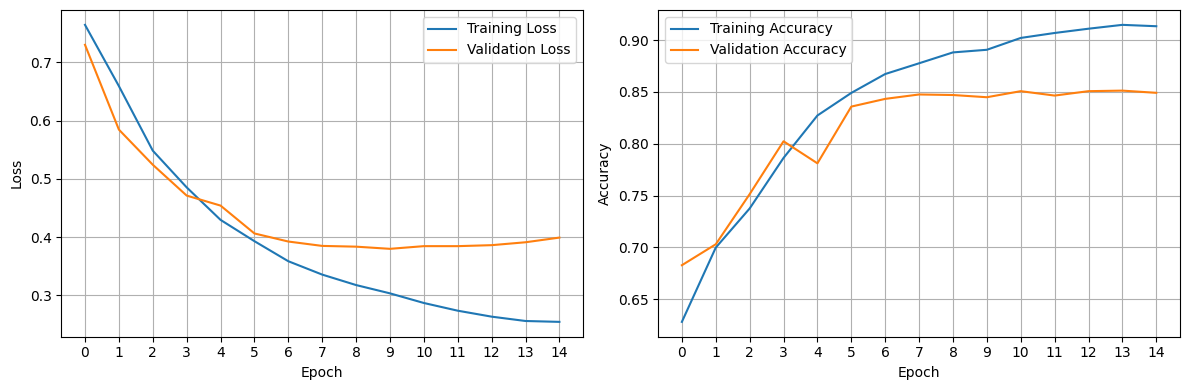

In [14]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history.history['loss']))

# Membuat plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Hilangkan 0.5, 1.5 dst
ax[0].set_xticks(list(epochs))

ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

# Hilangkan 0.5, 1.5 dst
ax[1].set_xticks(list(epochs))

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

       Stres     0.8283    0.8781    0.8524      1181
 Tidak Stres     0.8691    0.8164    0.8419      1171

    accuracy                         0.8474      2352
   macro avg     0.8487    0.8472    0.8472      2352
weighted avg     0.8486    0.8474    0.8472      2352



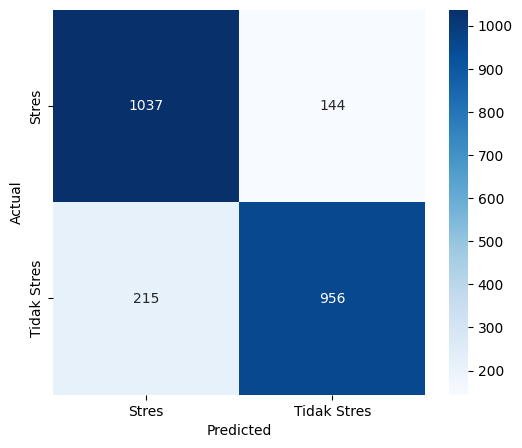

In [22]:


# Prediksi model
y_pred = model.predict(X_test)

# Karena sigmoid binary classification
y_pred_labels = (y_pred > 0.5).astype(int).reshape(-1)

# Jika y_test masih one-hot encoded
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true_labels = np.argmax(y_test, axis=1)
else:
    y_true_labels = y_test

# Label class
labels = ['Stres', 'Tidak Stres']

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=labels,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("")

plt.show()

Deep LSTM (2 Layer + Dropout)

In [18]:
model_2 = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    LSTM(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    LSTM(
        32,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

optimizer = Adam(learning_rate=0.0001)

model_2.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,473 (1.39 MB)

 Trainable params: 365,473 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 57s 200ms/step - accuracy: 0.6332 - loss: 0.8319 - val_accuracy: 0.6599 - val_loss: 0.7795
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 83s 204ms/step - accuracy: 0.6886 - loss: 0.7010 - val_accuracy: 0.7014 - val_loss: 0.6359
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 48s 202ms/step - accuracy: 0.7355 - loss: 0.6016 - val_accuracy: 0.7226 - val_loss: 0.5722
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.7709 - loss: 0.5367 - val_accuracy: 0.7641 - val_loss: 0.5166
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 47s 199ms/step - accuracy: 0.8113 - loss: 0.4696 - val_accuracy: 0.8087 - val_loss: 0.4745
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 82s 201ms/step - accuracy: 0.8412 - loss: 0.4207 - val_accuracy: 0.8156 - val_loss: 0.4482
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.8611 - loss: 0.3840 - val_accuracy: 0.8241 - val_loss: 0.4393
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 82s 202ms/step - accuracy: 0.8760 - loss: 0

In [20]:
loss_2, acc_2 = model_2.evaluate(X_test, y_test)
print("Test Accuracy Model 2:", acc_2)

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8406 - loss: 0.4250
Test Accuracy Model 2: 0.8405612111091614


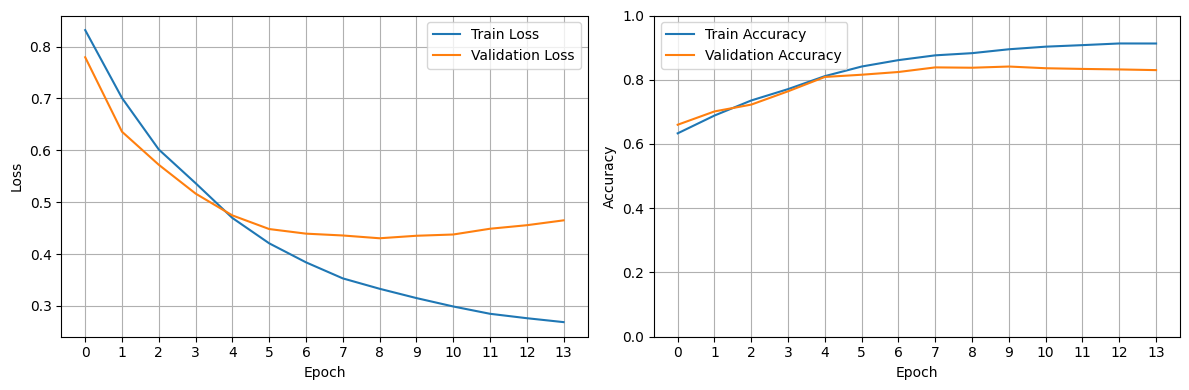

In [21]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history_2.history['loss']))

# Plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss dulu
ax[0].plot(epochs, history_2.history['loss'], label='Train Loss')
ax[0].plot(epochs, history_2.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[0].set_xticks(list(epochs))

ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, history_2.history['accuracy'], label='Train Accuracy')
ax[1].plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

ax[1].set_xticks(list(epochs))
ax[1].set_ylim(0, 1.0)

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
              precision    recall  f1-score   support

       Stres     0.8381    0.8459    0.8420      1181
 Tidak Stres     0.8431    0.8352    0.8391      1171

    accuracy                         0.8406      2352
   macro avg     0.8406    0.8405    0.8405      2352
weighted avg     0.8406    0.8406    0.8406      2352



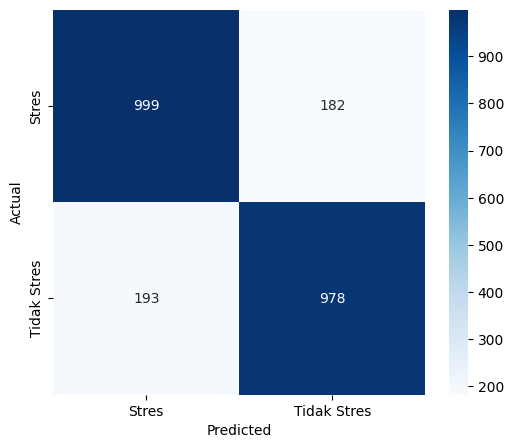

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi probabilitas
y_pred_prob = model_2.predict(X_test)

# Ubah ke label (0 / 1)
y_pred_labels = (y_pred_prob > 0.5).astype(int).reshape(-1)

# True label
y_true_labels = y_test

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=['Stres', 'Tidak Stres'],
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Visualisasi
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=['Stres', 'Tidak Stres'],
    yticklabels=['Stres', 'Tidak Stres']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("")
plt.show()

Bidirectional LSTM

In [25]:
model_3 = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    Bidirectional(
        LSTM(
            32,
            dropout=0.2,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(0.001)
        )
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

optimizer = Adam(learning_rate=0.0001)

model_3.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 52s 186ms/step - accuracy: 0.5788 - loss: 0.8310 - val_accuracy: 0.6583 - val_loss: 0.7942
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 44s 189ms/step - accuracy: 0.6867 - loss: 0.7453 - val_accuracy: 0.7051 - val_loss: 0.6929
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - accuracy: 0.7334 - loss: 0.6362 - val_accuracy: 0.7216 - val_loss: 0.5811
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.7654 - loss: 0.5517 - val_accuracy: 0.7742 - val_loss: 0.5241
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 167ms/step - accuracy: 0.8062 - loss: 0.4907 - val_accuracy: 0.8209 - val_loss: 0.4823
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.8355 - loss: 0.4488 - val_accuracy: 0.8273 - val_loss: 0.4450
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 160ms/step - accuracy: 0.8545 - loss: 0.4056 - val_accuracy: 0.8369 - val_loss: 0.4207
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.8530 - loss: 0

In [27]:
loss_3, acc_3 = model_3.evaluate(X_test, y_test)
print("Test Accuracy Model 3:", acc_3)

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8533 - loss: 0.3759
Test Accuracy Model 3: 0.8533163070678711


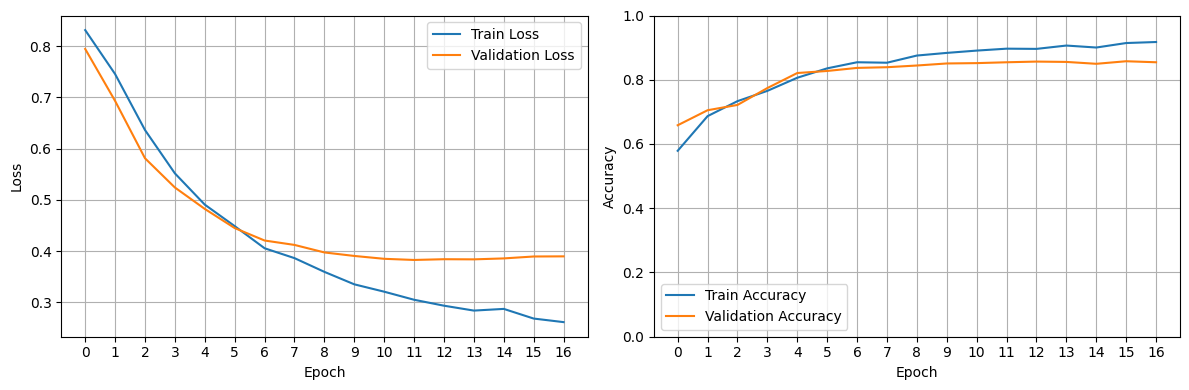

In [28]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history_3.history['loss']))

# Plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss dulu
ax[0].plot(epochs, history_3.history['loss'], label='Train Loss')
ax[0].plot(epochs, history_3.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Hilangkan 0.5, 1.5 dst
ax[0].set_xticks(list(epochs))

# Hapus jika loss > 1
# ax[0].set_ylim(0, 1.0)

ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, history_3.history['accuracy'], label='Train Accuracy')
ax[1].plot(epochs, history_3.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

# Hilangkan 0.5, 1.5 dst
ax[1].set_xticks(list(epochs))

ax[1].set_ylim(0, 1.0)

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step
              precision    recall  f1-score   support

 Tidak Stres     0.8432    0.8696    0.8562      1181
       Stres     0.8642    0.8369    0.8503      1171

    accuracy                         0.8533      2352
   macro avg     0.8537    0.8532    0.8533      2352
weighted avg     0.8536    0.8533    0.8533      2352



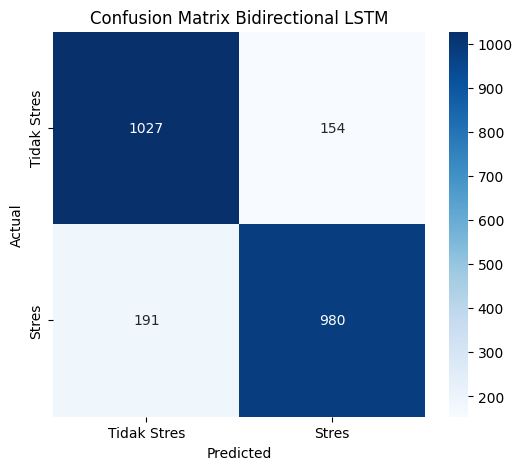

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi
y_pred_prob = model_3.predict(X_test)
y_pred_labels = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Label asli
y_true_labels = y_test

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=['Tidak Stres', 'Stres'],
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Stres', 'Stres'],
    yticklabels=['Tidak Stres', 'Stres']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Bidirectional LSTM")

plt.show()

In [ ]:
model.save('../../Model/model_lstm_stress.h5')
with open('../../Model/tokenizer_stress.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
model.save('../../Model/model_lstm_stress.keras')

In [ ]:
import json

with open("../../Model/tokenizer.json", "w") as f:
    json.dump(tokenizer.word_index, f)